## **가격 크롤링 데이터**

### **1. long data 만들기**

일단은 수정사항: long data 로 만들어야 한다. 

모든 통계적 계산은 long data로 하고 (df_long로 저장함.), 

가격 판별한 뒤에 상호명 뽑을 때만 df_price 데이터 사용하기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

In [3]:
df = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/98_광진구 가격 데이터.csv")
df.head(20)

,가게명,주메뉴,동,메뉴1,가격1,메뉴2,가격2
0,백일도,회,중곡동,광어&연어,30000,광어&우럭&연어,40000
1,도톰 본점,"육류,고기",중곡동,도톰삼겹살 (180g),16000,도톰목살 (180g),16000
2,포차조개구이,특수 해산물,중곡동,모듬 조개찜 (소),55000,모듬 조개구이 (중),55000
3,택이네조개전골 군자역점,특수 해산물,중곡동,조개전골 (2인),49000,조개 칼국수,11000
4,장군갈비,갈비,중곡동,생갈비 (1인분),65000,양념갈비 (1인분),54000
5,치바우뼈다귀 중곡점,특수 탕류,중곡동,감자탕(소),25000,감자탕(중),30000
6,소랑도,회,중곡동,삼치회,35000,병어,35000
7,힘찬갯벌낙지,"해물,생선",중곡동,산낙지 탕탕이,30000,육회탕탕이,45000
8,크래버 대게나라 광장점,특수 해산물,중곡동,대게탕,25000,게장볶음밥,12000
9,홍별감네,삼겹살,중곡동,차돌된장샤브샤브 (1인분),25000,두루치기 (1인분),14000


In [4]:
df_price = df.copy()

df1 = df[['메뉴1','가격1','가게명','주메뉴','동']].copy()
df1.columns = ['메뉴','가격','가게명','주메뉴','동']

df2 = df[['메뉴2','가격2','가게명','주메뉴','동']].copy()
df2.columns = ['메뉴','가격','가게명','주메뉴','동']

df_long = pd.concat([df1,df2], ignore_index=True)

df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5238 entries, 0 to 5237
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      5238 non-null   object
 1   가격      5238 non-null   int64 
 2   가게명     5238 non-null   object
 3   주메뉴     5238 non-null   object
 4   동       5238 non-null   object
dtypes: int64(1), object(4)
memory usage: 204.7+ KB


In [5]:
df_price['가격1'] = pd.to_numeric(df_price['가격1'], errors='coerce')
df_price['가격2'] = pd.to_numeric(df_price['가격2'], errors='coerce')
df_long['가격'] = pd.to_numeric(df_long['가격'], errors = 'coerce')

In [6]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2619 entries, 0 to 2618
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   가게명     2619 non-null   object
 1   주메뉴     2619 non-null   object
 2   동       2619 non-null   object
 3   메뉴1     2619 non-null   object
 4   가격1     2619 non-null   int64 
 5   메뉴2     2619 non-null   object
 6   가격2     2619 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 143.4+ KB


In [7]:
df_long.head(20)

,메뉴,가격,가게명,주메뉴,동
0,광어&연어,30000,백일도,회,중곡동
1,도톰삼겹살 (180g),16000,도톰 본점,"육류,고기",중곡동
2,모듬 조개찜 (소),55000,포차조개구이,특수 해산물,중곡동
3,조개전골 (2인),49000,택이네조개전골 군자역점,특수 해산물,중곡동
4,생갈비 (1인분),65000,장군갈비,갈비,중곡동
5,감자탕(소),25000,치바우뼈다귀 중곡점,특수 탕류,중곡동
6,삼치회,35000,소랑도,회,중곡동
7,산낙지 탕탕이,30000,힘찬갯벌낙지,"해물,생선",중곡동
8,대게탕,25000,크래버 대게나라 광장점,특수 해산물,중곡동
9,차돌된장샤브샤브 (1인분),25000,홍별감네,삼겹살,중곡동


## **2. 시각화**

long data 에서, 주메뉴별로 데이터를 시각화하는 경우

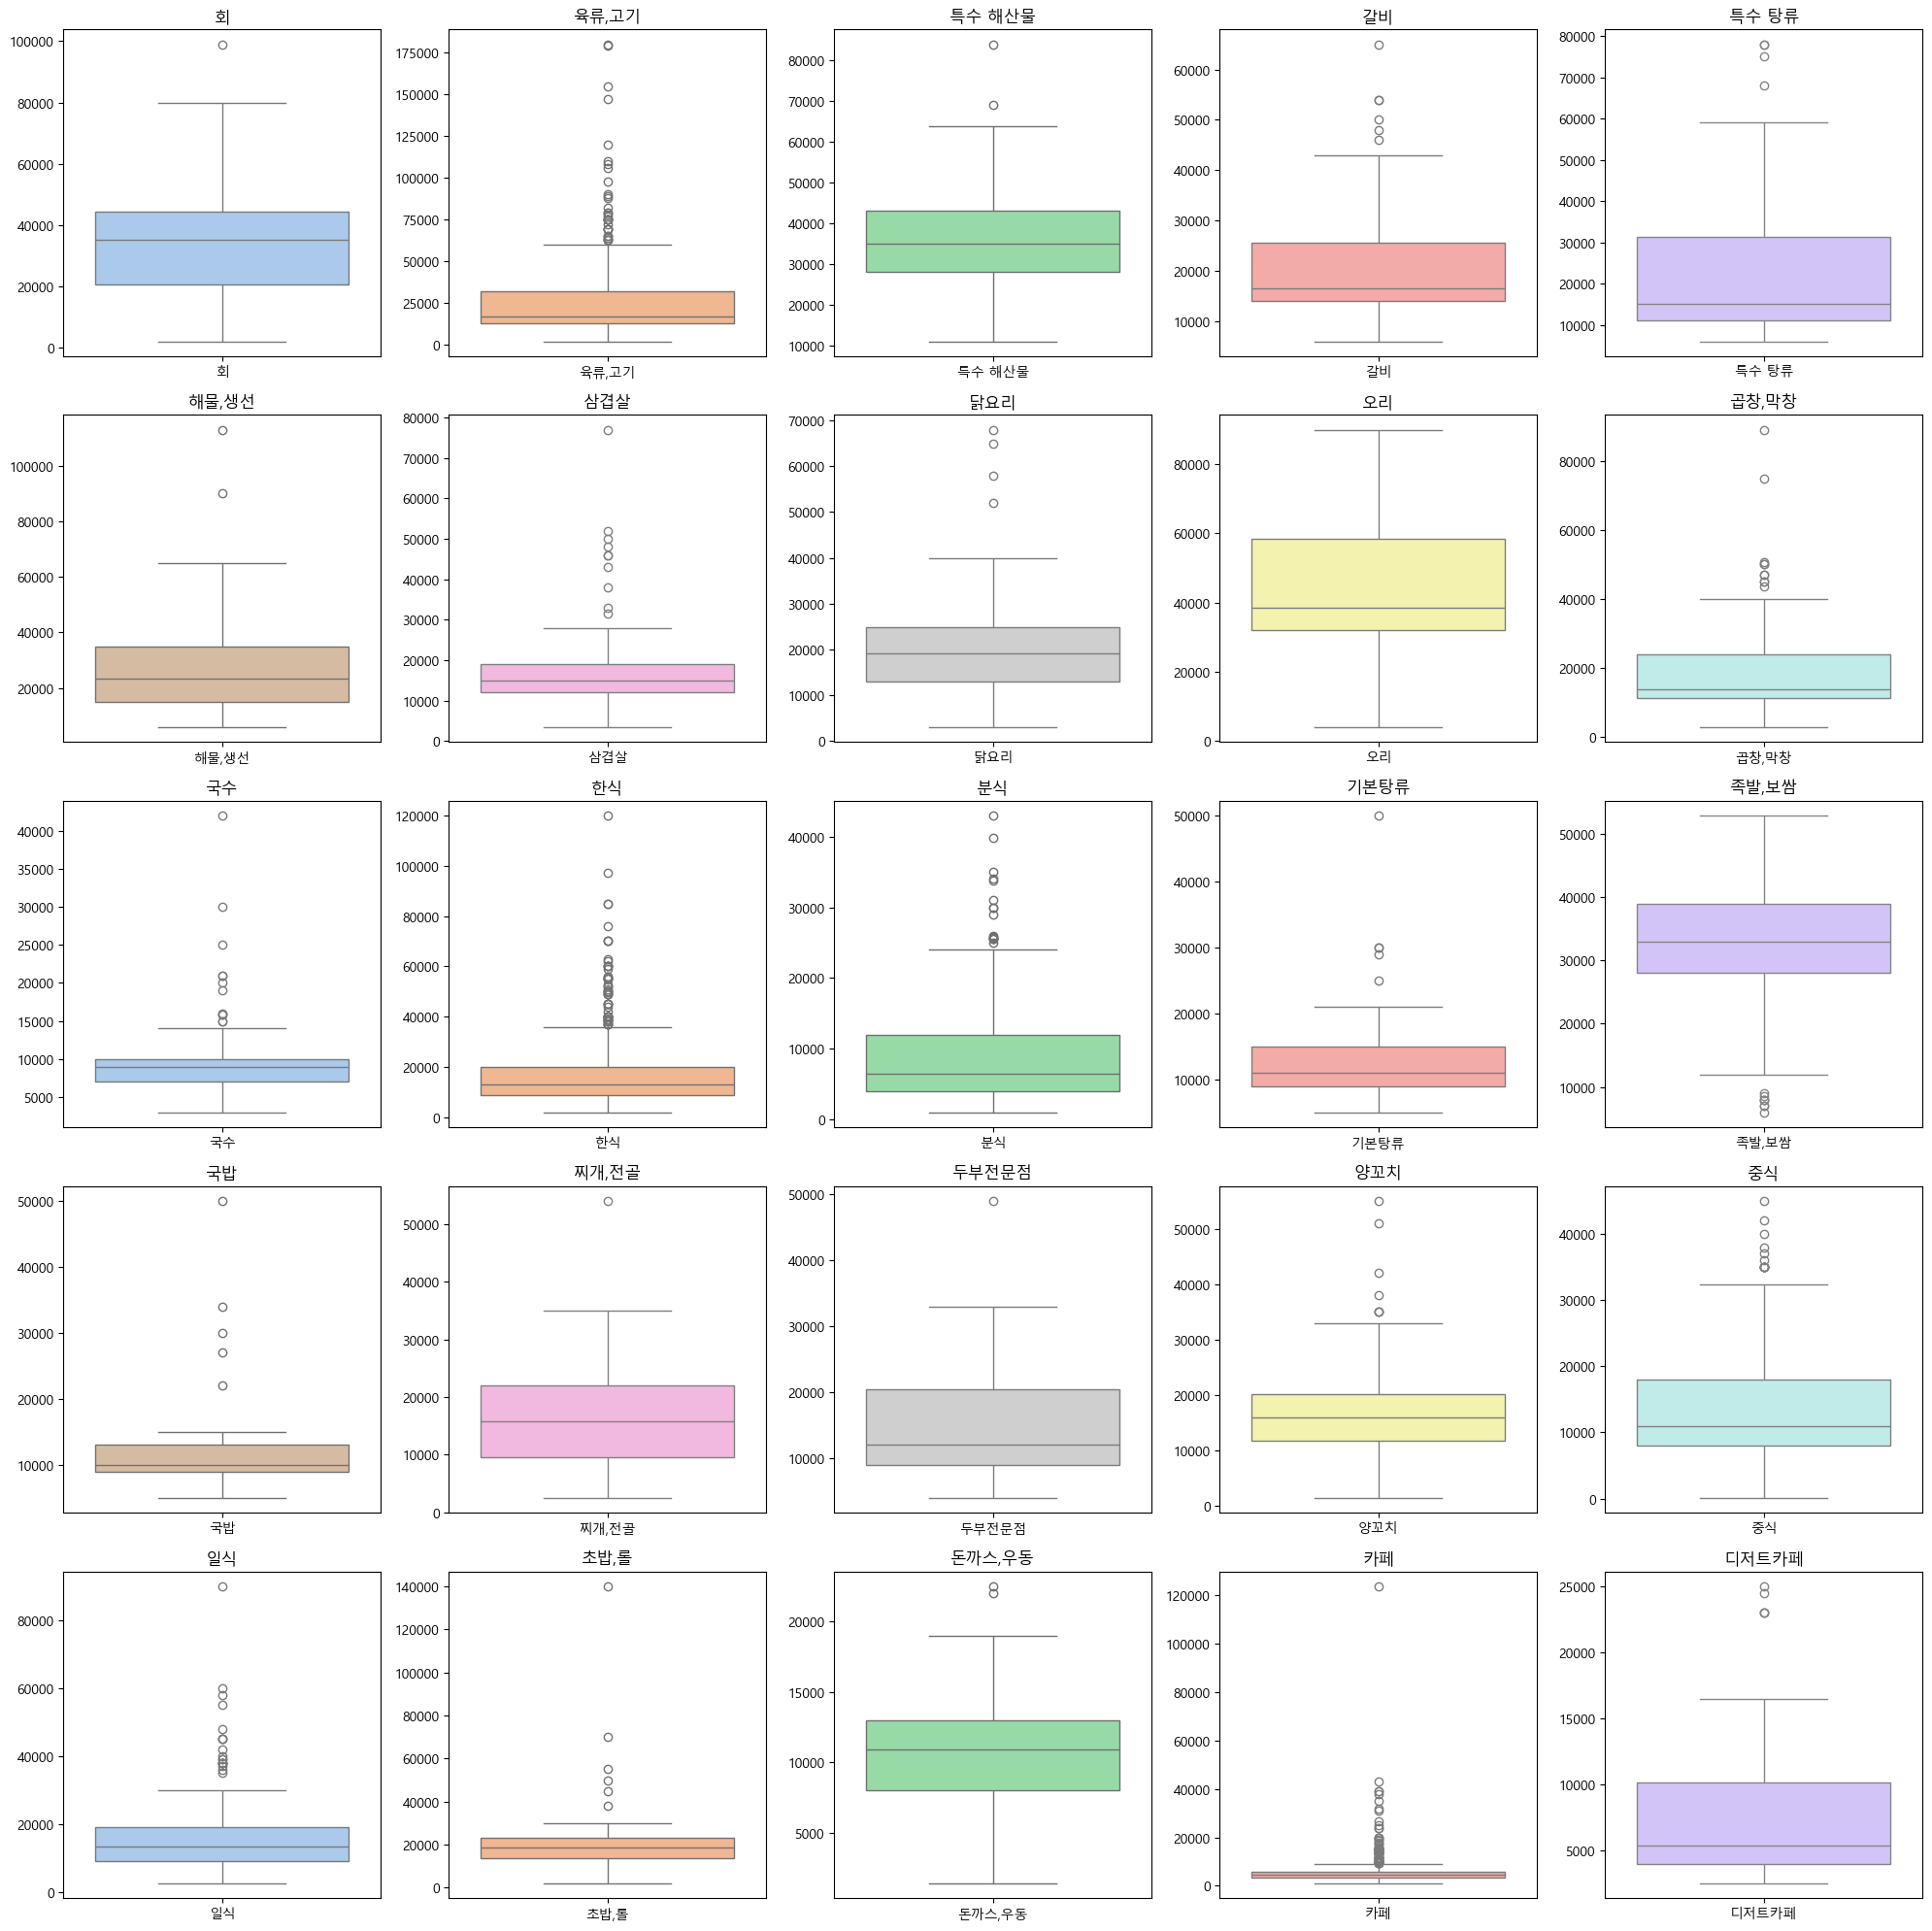

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))  
axes = axes.flatten()  

menu_list = df_long['주메뉴'].unique()
palette = sns.color_palette("pastel", n_colors=len(menu_list))

for i, (menu, color) in enumerate(zip(menu_list, palette)):
    sns.boxplot(x='주메뉴', y='가격', data=df_long[df_long['주메뉴'] == menu], ax=axes[i],
                hue='주메뉴', palette=[color], legend=False)
    axes[i].set_title(menu)
    #axes[i].set_ylim(0,80000)
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# 이상치가 많이 없는 것들: 회/ 특수 해산물/ 특수 탕류/ 해물,생선/ 갈비/ 닭요리/ 곱창,막창/ 기본탕류/ 국밥/ 초밥,롤/ 양꼬치/ 중식 
# 이상치가 너무 많은것들: 육류,고기/ 삼겹살/ 한식/ 분식/ 일식/ 
# 이상치 없는 것들: 오리/ 찌개,전골/ 두부전문점/ 돈까스,우동/ 디저트카페/ 
# 이상치 처리가 필요한 것들: 족발,보쌈쌈

In [ ]:
count_df = df_long.groupby('주메뉴')['가게명'].count().reset_index()
count_df   

,주메뉴,가게명
0,갈비,122
1,"곱창,막창",150
2,국밥,74
3,국수,182
4,기본탕류,52
5,닭요리,142
6,"돈까스,우동",158
7,두부전문점,28
8,디저트카페,140
9,분식,480


## **3. 전처리**

이상치 그냥 날릴 메뉴들: '회','특수 해산물','갈비','특수 탕류','해물,생선','닭요리','오리','국수','기본탕류','국밥','찌개,전골','두부전문점','양꼬치','초밥,롤','돈까스,우동','디저트카페'

이상치 처리가 따로 필요한 메뉴들: 1. 육류,고기 2. 삼겹살 3. 곱창막창 4. 한식 5. 분식 6. 족발,보쌈 7. 중식 8. 일식 9. 카페

In [ ]:
df_long = df_long.sort_values(by='주메뉴')
df_long.head()

,메뉴,가격,가게명,주메뉴,동
3509,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동
512,소양념왕갈비(300g),23000,마포갈비,갈비,구의동
582,차돌된장찌개,10000,서울숯불갈비,갈비,구의동
3668,삼겹살(200g),18000,낙천정,갈비,자양동
649,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동


In [ ]:
df_meat = df_long[df_long['주메뉴']=='육류,고기']
df_pork = df_long[df_long['주메뉴']=='삼겹살']
df_gop = df_long[df_long['주메뉴']=='곱창,막창']
df_kor = df_long[df_long['주메뉴']=='한식']
df_bun = df_long[df_long['주메뉴']=='분식']
df_jok = df_long[df_long['주메뉴']=='족발,보쌈']
df_china = df_long[df_long['주메뉴']=='중식']
df_japan = df_long[df_long['주메뉴']=='일식']
df_cafe = df_long[df_long['주메뉴']=='카페']


In [ ]:
# 이상치가 적은 주메뉴에 대해, 이상치 삭제

delete = ['회','특수 해산물','갈비','특수 탕류','해물,생선','닭요리','오리','국수','기본탕류','국밥',
          '찌개,전골','두부전문점','양꼬치','초밥,롤','돈까스,우동','디저트카페']
drop_idx = []

for menu in delete:
    subset = df_long[df_long['주메뉴'] == menu]
    price = subset['가격']
    
    Q1 = price.quantile(0.25)
    Q3 = price.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = subset[(price < lower_bound) | (price > upper_bound)].index
    drop_idx.extend(outliers)

df_long = df_long.drop(index=drop_idx).reset_index(drop=True)

In [ ]:
df_left = df_long[df_long['주메뉴'].isin(delete)].copy()
df_left.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1571 entries, 0 to 5174
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      1571 non-null   object
 1   가격      1571 non-null   int64 
 2   가게명     1571 non-null   object
 3   주메뉴     1571 non-null   object
 4   동       1571 non-null   object
dtypes: int64(1), object(4)
memory usage: 73.6+ KB


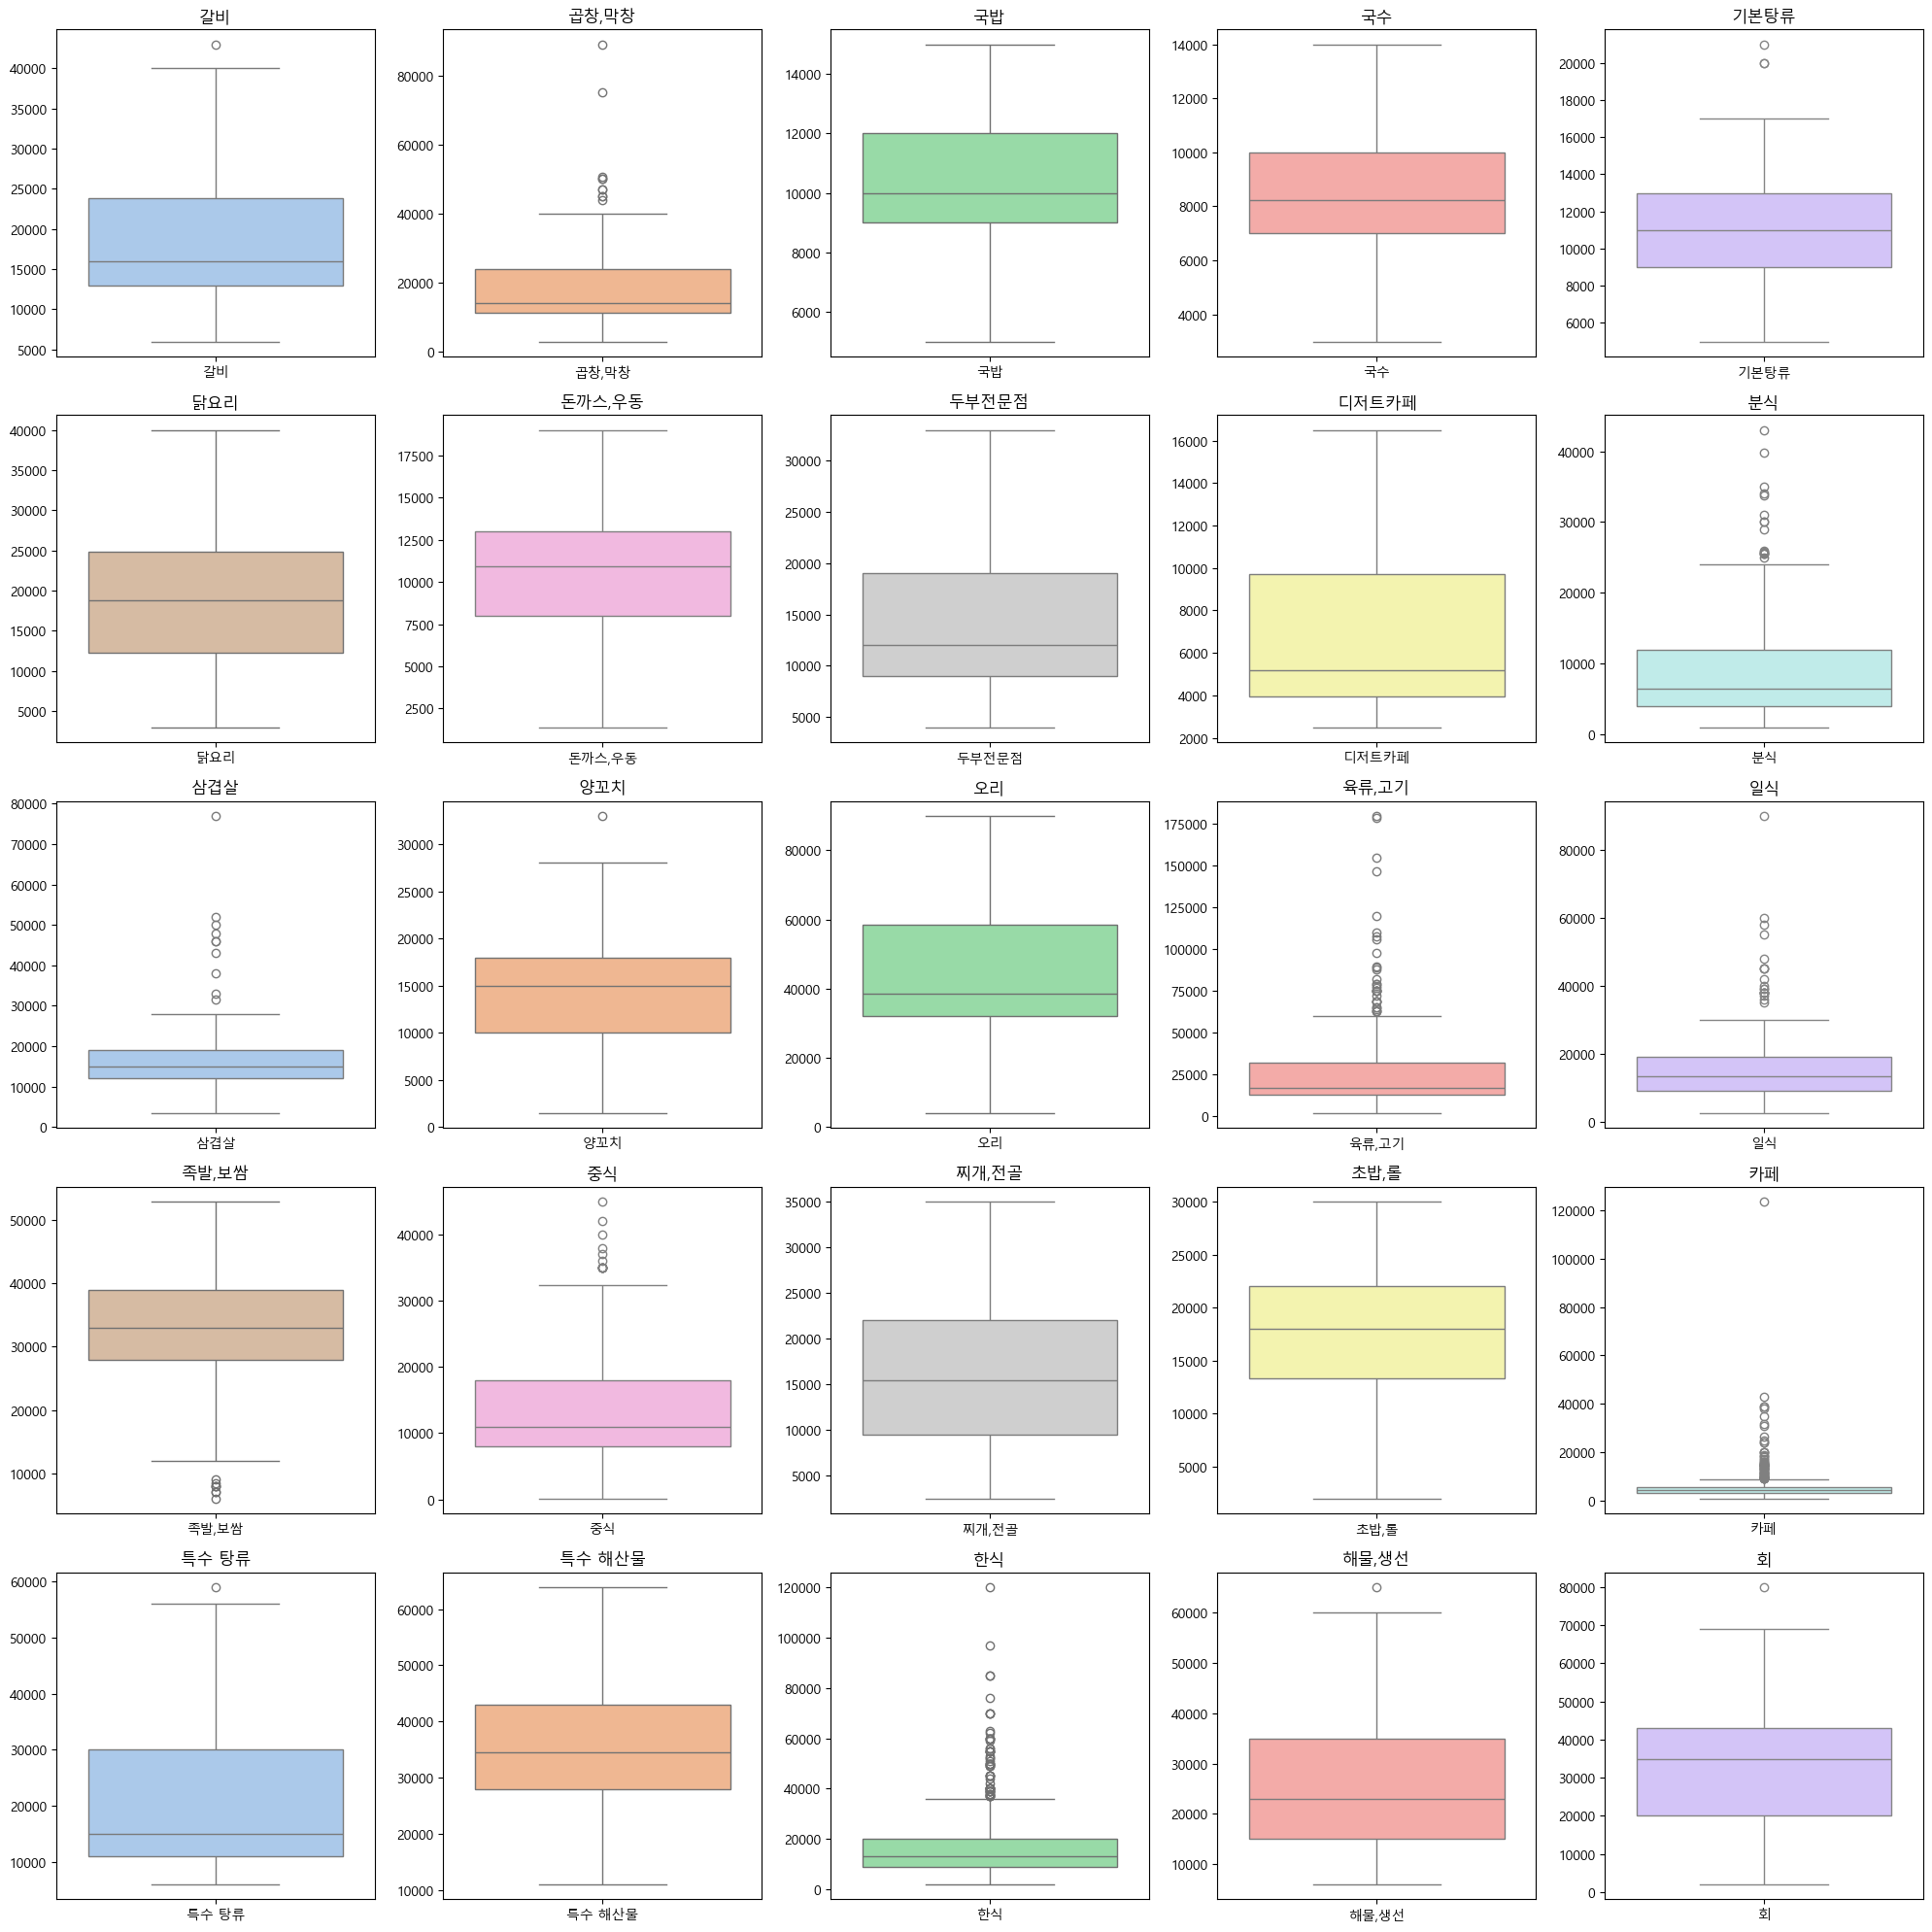

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))  
axes = axes.flatten()  

menu_list = df_long['주메뉴'].unique()
palette = sns.color_palette("pastel", n_colors=len(menu_list))

for i, (menu, color) in enumerate(zip(menu_list, palette)):
    sns.boxplot(x='주메뉴', y='가격', data=df_long[df_long['주메뉴'] == menu], ax=axes[i],
                hue='주메뉴', palette=[color], legend=False)
    axes[i].set_title(menu)
    #axes[i].set_ylim(0,80000)
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## **이상치 처리**

### **1. '육류,고기' 이상치 처리 과정**

1.  데이터를 처음 확인한 결과 '메뉴'에 '콜라'나 '조리값' 등의 이상한 데이터가 포함되어있음을 확인하였음. 이를 해결하기 위해

    '육류,고기'의 경우 '메뉴'에 특정 이름이 포함되는지 여부를 통해 1차적으로 메뉴들을 걸러내었음.

    예를 들어, '고기','갈비','한우','삼(겹살)','육','g'등의 단어가 '메뉴'에 들어간다면 그러한 메뉴들만 남김.

2. 그리고 50000원 이하의 데이터들만 사용하였음.



In [ ]:
df_meat['가격'].describe()

count       432.000000
mean      26156.944444
std       23465.294468
min        2000.000000
25%       13000.000000
50%       17000.000000
75%       32000.000000
max      180000.000000
Name: 가격, dtype: float64

In [ ]:
df_meat.sort_values(by='가격').head()

,메뉴,가격,가게명,주메뉴,동
224,코카콜라355mL,2000,천호곱창치킨앤포차,"육류,고기",중곡동
529,스테이크 조리값,2500,더미트,"육류,고기",구의동
1193,특미볶음밥,3000,정통집 건대점,"육류,고기",화양동
521,삼겹살(110g),3900,화전별당,"육류,고기",구의동
3099,별미(멸치)국수,4000,장위동유성집,"육류,고기",구의동


In [ ]:
# 조건 만들기
condition = (
    df_meat['메뉴'].str.contains('살') |
    df_meat['메뉴'].str.contains('삼') |
    df_meat['메뉴'].str.contains('육') |
    df_meat['메뉴'].str.contains('g')
)

# 조건을 만족하는 행들 저장
df_meat_temp = df_meat[condition].copy()

# 원래 데이터에서는 조건을 만족하는 행들 제거
df_meat = df_meat[~condition].reset_index(drop=True)

df_meat_temp.head()

,메뉴,가격,가게명,주메뉴,동
707,황제갈비살 (100g),7900,압구정화로구이 군자역점,"육류,고기",군자동
3620,토시살,10800,백삼호,"육류,고기",자양동
464,소한마리(600g),79000,한마음정육식당 구의강변점,"육류,고기",구의동
416,제육불고기 도시락,8900,배가네논밭집,"육류,고기",구의동
414,A세트(2~3인분 500g),40000,숙고,"육류,고기",구의동


In [ ]:
df_meat_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295 entries, 707 to 1246
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      295 non-null    object
 1   가격      295 non-null    int64 
 2   가게명     295 non-null    object
 3   주메뉴     295 non-null    object
 4   동       295 non-null    object
dtypes: int64(1), object(4)
memory usage: 13.8+ KB


In [ ]:
df_meat.head()

,메뉴,가격,가게명,주메뉴,동
0,미 세트 (2~3인분),45000,미가육,"육류,고기",구의동
1,백반,8000,마가을고기 어린이대공원점,"육류,고기",군자동
2,등심(1인분),40000,철원정육식당 본점,"육류,고기",중곡동
3,한우양념갈비정식,155000,비스타워커힐서울 명월관,"육류,고기",광장동
4,한우등심(2인),98000,장위동유성집,"육류,고기",구의동


In [ ]:
keywords = ['고기', '갈비', '한우', '차돌박이','생','심','돼지']

for keyword in keywords:
    condition2 = df_meat['메뉴'].str.contains(keyword)
    
    # 해당하는 데이터 있으면
    temp = df_meat[condition2].copy()
    df_meat_temp = pd.concat([df_meat_temp, temp], ignore_index=True)
    
    # 원본에서는 제거
    df_meat = df_meat[~condition2].reset_index(drop=True)

In [ ]:
df_meat.head()

,메뉴,가격,가게명,주메뉴,동
0,미 세트 (2~3인분),45000,미가육,"육류,고기",구의동
1,백반,8000,마가을고기 어린이대공원점,"육류,고기",군자동
2,[압도적 1위] 직화 반반 뼈구이,39000,동네맛집뼈구이집 구의점,"육류,고기",구의동
3,양양꼬치(10ea),12000,양양 건대점,"육류,고기",화양동
4,부대찌개,7000,성동식당,"육류,고기",구의동


In [ ]:
df_meat_temp.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
206,살치살 (360g),120000,늘조은한우 구의직영점,"육류,고기",자양동
330,한우 투뿔 1++ 오마카세 3인 세트,147000,지즐미육회관 구의점,"육류,고기",구의동
312,한우양념갈비정식,155000,비스타워커힐서울 명월관,"육류,고기",광장동
335,한우등심정식,179000,비스타워커힐서울 명월관,"육류,고기",광장동
31,한우600g세트,180000,일상예우,"육류,고기",구의동


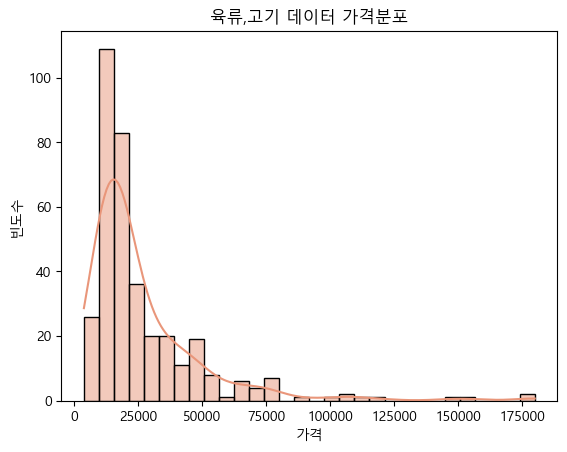

In [ ]:
sns.histplot(data=df_meat_temp, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('육류,고기 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

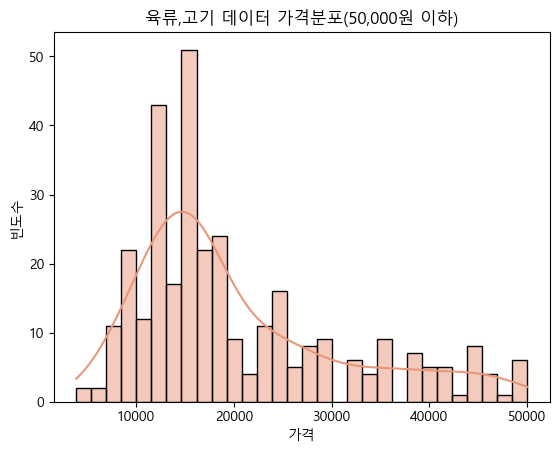

In [ ]:
sns.histplot(data=df_meat_temp[df_meat_temp['가격']<=50000],
              x='가격', bins=30, kde=True, color='darksalmon')
plt.title('육류,고기 데이터 가격분포(50,000원 이하)')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
# final data

df_meat = df_meat_temp[df_meat_temp['가격']<=50000]
df_meat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 359
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      324 non-null    object
 1   가격      324 non-null    int64 
 2   가게명     324 non-null    object
 3   주메뉴     324 non-null    object
 4   동       324 non-null    object
dtypes: int64(1), object(4)
memory usage: 15.2+ KB


### **2. '삼겹살' 이상치 처리**

In [ ]:
df_pork['가격'].describe()

count      110.000000
mean     17070.909091
std      11257.489621
min       3500.000000
25%      12125.000000
50%      15000.000000
75%      18975.000000
max      77000.000000
Name: 가격, dtype: float64

In [ ]:
df_pork.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
3801,삼겹모듬한판(2인),46000,돼봉삼겹살 건대점,삼겹살,화양동
2659,살치살,48000,고오기,삼겹살,중곡동
843,모듬,50000,싸리골,삼겹살,능동
40,새우살,52000,고오기,삼겹살,중곡동
3145,한판세트 (900g),77000,상구네솥뚜껑삼겹살 구의점,삼겹살,구의동


In [ ]:
condition = (
    df_pork['메뉴'].str.contains('살') |
    df_pork['메뉴'].str.contains('목살') |
    df_pork['메뉴'].str.contains('차돌박이') |
    df_pork['메뉴'].str.contains('돼지') |
    df_pork['메뉴'].str.contains('등심') |
    df_pork['메뉴'].str.contains('고기') |
    df_pork['메뉴'].str.contains('삼겹')
)

df_pork_temp = df_pork[condition].copy()
df_pork = df_pork[~condition].reset_index(drop=True)

df_pork_temp.head()

,메뉴,가격,가게명,주메뉴,동
3244,대패삼겹살(180g),15000,은둔고수,삼겹살,구의동
3740,통큰 고기만 숯불갈비（공기밥 별도）,28000,헬로통큰삼겹 자양점,삼겹살,자양동
2734,오겹살(170g),16000,왕솥뚜껑생삼겹살,삼겹살,중곡동
790,1인고기도시락 (ft.간편식도시락),15500,돈삼촌삼겹살배달전문점 건대점,삼겹살,군자동
3025,목살,7900,꽃삼뚜껑 구의역직영점,삼겹살,구의동


In [ ]:
df_pork_temp.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
183,꽃등심 (1인분),33000,마장솥뚜껑,삼겹살,중곡동
169,소고기한판(400g),38000,아차산흑돼지,삼겹살,중곡동
3801,삼겹모듬한판(2인),46000,돼봉삼겹살 건대점,삼겹살,화양동
2659,살치살,48000,고오기,삼겹살,중곡동
40,새우살,52000,고오기,삼겹살,중곡동


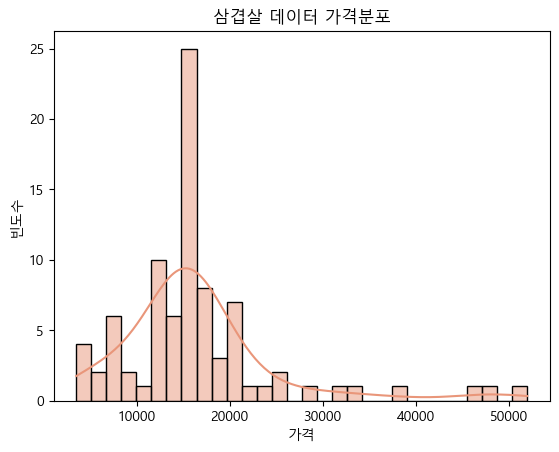

In [ ]:
sns.histplot(data=df_pork_temp, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('삼겹살 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
df_pork_temp['가격'].describe()

count       85.000000
mean     16547.058824
std       8624.944282
min       3500.000000
25%      13000.000000
50%      15000.000000
75%      17000.000000
max      52000.000000
Name: 가격, dtype: float64

In [ ]:
# final data

df_pork = df_pork_temp[df_pork_temp['가격']<=40000]

### **3. '곱창,막창' 이상치 처리**

In [ ]:
df_gop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1120 to 3009
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      150 non-null    object
 1   가격      150 non-null    int64 
 2   가게명     150 non-null    object
 3   주메뉴     150 non-null    object
 4   동       150 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.0+ KB


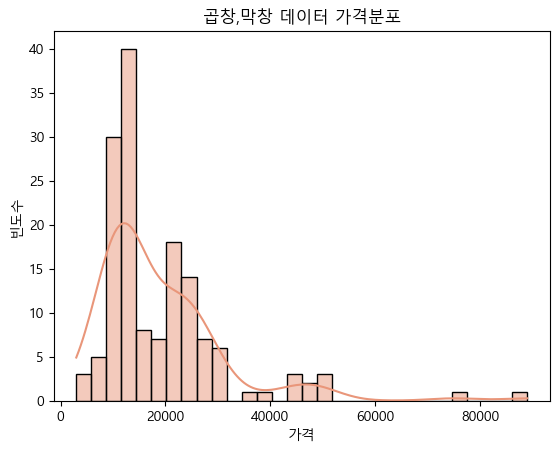

In [ ]:
sns.histplot(data=df_gop, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('곱창,막창 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
df_gop.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
1018,곱창한판,50000,동춘돌곱창 자양점,"곱창,막창",자양동
3637,동춘모듬,50000,동춘돌곱창 자양점,"곱창,막창",자양동
3296,한우소곱창모듬구이,50800,와우곱창,"곱창,막창",구의동
2967,모듬 (대),75000,광나루소곱창,"곱창,막창",광장동
348,모듬 (특대),89000,광나루소곱창,"곱창,막창",광장동


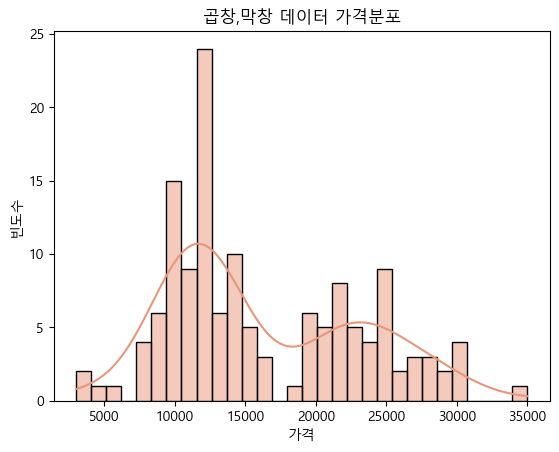

In [ ]:
# final data

df_gop = df_gop[df_gop['가격']<40000]

sns.histplot(data=df_gop, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('곱창,막창 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

### **4. '한식' 이상치 처리**

In [ ]:
df_kor.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824 entries, 417 to 3936
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      824 non-null    object
 1   가격      824 non-null    int64 
 2   가게명     824 non-null    object
 3   주메뉴     824 non-null    object
 4   동       824 non-null    object
dtypes: int64(1), object(4)
memory usage: 38.6+ KB


In [ ]:
df_kor['가격'].describe()

count       824.000000
mean      17022.427184
std       12618.646733
min        2000.000000
25%        9000.000000
50%       13000.000000
75%       20000.000000
max      120000.000000
Name: 가격, dtype: float64

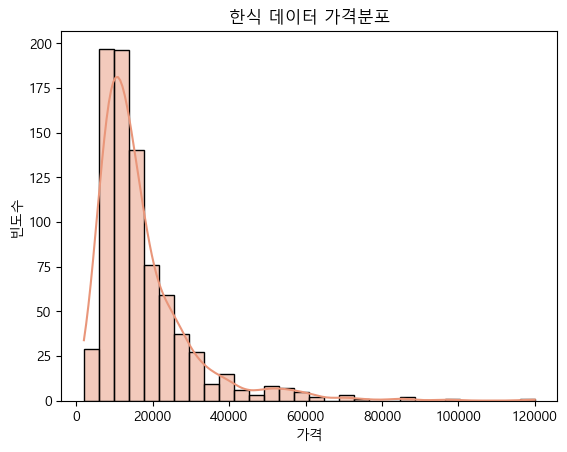

In [ ]:
sns.histplot(data=df_kor, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('한식 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

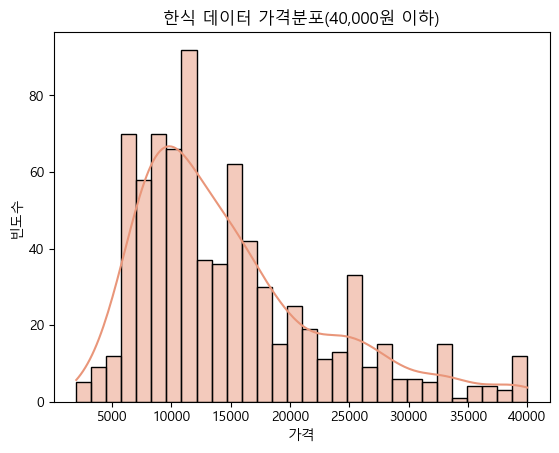

In [ ]:
sns.histplot(data=df_kor[df_kor['가격']<=40000], x='가격', bins=30, kde=True, color='darksalmon')
plt.title('한식 데이터 가격분포(40,000원 이하)') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
# final data

df_kor = df_kor[df_kor['가격'] <= 40000]

### **5. '분식' 이상치 처리**

In [ ]:
df_bun['가격'].describe()

count      480.000000
mean      9028.958333
std       6725.579420
min       1000.000000
25%       4000.000000
50%       6500.000000
75%      12000.000000
max      43000.000000
Name: 가격, dtype: float64

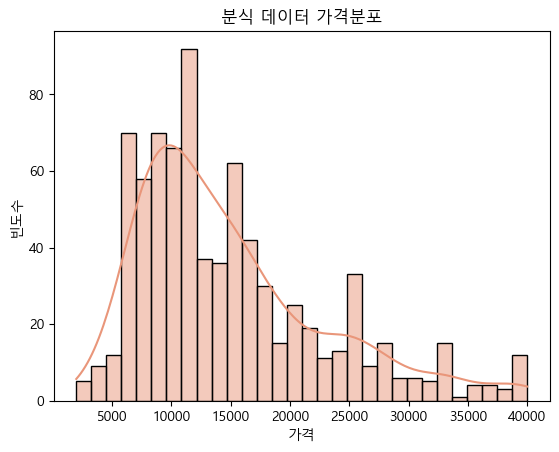

In [ ]:
sns.histplot(data=df_kor, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('분식 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

### **6. '족발,보쌈' 이상치 처리**

In [ ]:
df_jok['가격'].describe()

count       96.000000
mean     31082.291667
std      11008.542088
min       6000.000000
25%      27975.000000
50%      33000.000000
75%      39000.000000
max      52900.000000
Name: 가격, dtype: float64

In [ ]:
df_jok.sort_values(by='가격').head(20)

,메뉴,가격,가게명,주메뉴,동
2697,순대국,6000,제일족발곱창,"족발,보쌈",중곡동
3085,쟁반막국수,7000,족발명가,"족발,보쌈",구의동
78,곱창,7000,제일족발곱창,"족발,보쌈",중곡동
3445,메밀 들깨칼국수,8000,정원,"족발,보쌈",능동
709,국밥,8000,해미보쌈순대국,"족발,보쌈",군자동
3328,순대국,8000,해미보쌈순대국,"족발,보쌈",군자동
3926,스테이크보쌈도시락,8500,궁중보쌈 스테이크보쌈,"족발,보쌈",화양동
2772,국수,9000,흥부왕족발,"족발,보쌈",중곡동
545,설렁탕,12000,장수원설렁탕,"족발,보쌈",구의동
826,마늘보쌈정식,12000,정원,"족발,보쌈",능동


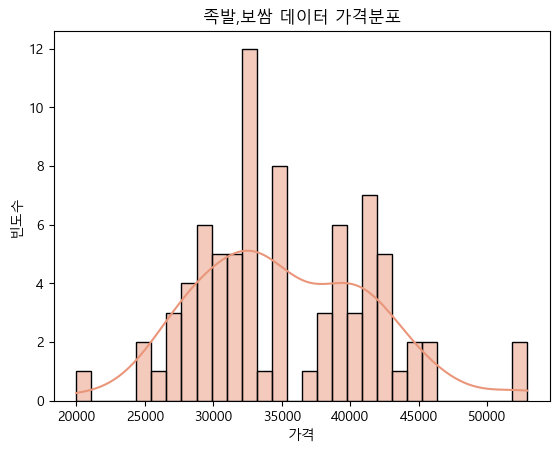

In [ ]:
sns.histplot(data=df_jok[df_jok['가격'] >= 20000],
              x='가격', bins=30, kde=True, color='darksalmon')
plt.title('족발,보쌈 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
# final data

df_jok = df_jok[df_jok['가격'] >= 20000]

### **7. '중식' 이상치 처리**

In [ ]:
df_china['가격'].describe()

count      356.000000
mean     13501.966292
std       8202.168834
min        100.000000
25%       8000.000000
50%      10900.000000
75%      18000.000000
max      45000.000000
Name: 가격, dtype: float64

In [ ]:
df_china = df_china[df_china['가격'] >= 4000].copy()
df_china.sort_values(by='가격').head()

,메뉴,가격,가게명,주메뉴,동
4206,미친오리날개목,4000,미친판다,중식,자양동
1587,매운닭발,4000,미친판다,중식,자양동
1431,짜장면,4000,옛날짜장짬뽕,중식,중곡동
1433,짜장면,4000,직화짬뽕전문점 중곡직영점,중식,중곡동
1488,짜장면,4000,석기시대짜장마을,중식,군자동


In [ ]:
df_china.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
4224,바오탕수육 & 김치치즈탕수육 세트,37000,바오탕수 자양점,중식,자양동
1572,쏸차이위,38000,몽다래향라관,중식,자양동
1601,마라꽃게 (소),40000,마라유혹,중식,자양동
1434,안주셋트,42000,천리향,중식,중곡동
1592,개고기전골 (대),45000,투도식당,중식,자양동


In [ ]:
condition = (
    df_china['메뉴'].str.contains('짬뽕') |
    df_china['메뉴'].str.contains('짜장')
)

df_china_temp = df_china[condition].copy()
df_china = df_china[~condition].reset_index(drop=True)

df_china_temp.head()

,메뉴,가격,가게명,주메뉴,동
4129,삼선간짜장+프라이,10000,송쉐프 구의점,중식,자양동
4055,짬뽕,6000,애래향,중식,중곡동
4047,짬뽕,9000,아차성,중식,중곡동
4061,짬뽕면,8000,장순루,중식,광장동
4050,짬뽕,6000,옛날짜장짬뽕,중식,중곡동


In [ ]:
lst_temp = ['우동','자장','볶음밥','덮밥']

for keyword in lst_temp:
    condition2 = df_china['메뉴'].str.contains(keyword)
    
    temp = df_china[condition2].copy()
    df_china_temp = pd.concat([df_china_temp, temp], ignore_index=True)
    
    df_china = df_china[~condition2].reset_index(drop=True)

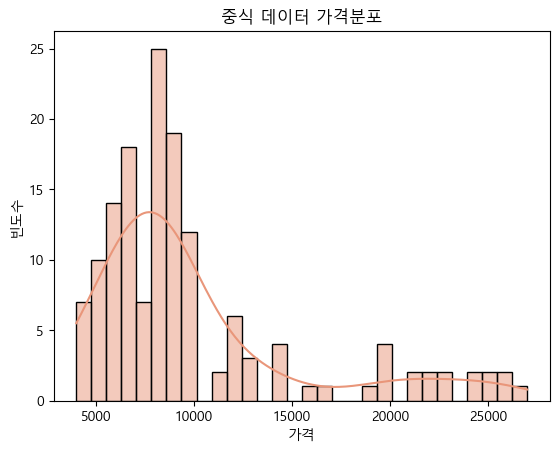

In [ ]:
sns.histplot(data=df_china_temp, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('중식 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

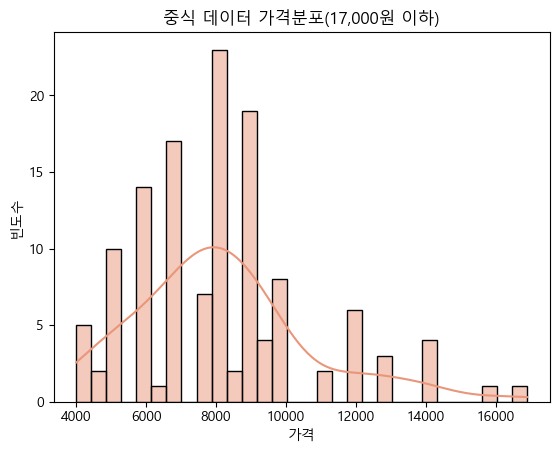

In [ ]:
sns.histplot(data=df_china_temp[df_china_temp['가격']<=17000],
              x='가격', bins=30, kde=True, color='darksalmon')
plt.title('중식 데이터 가격분포(17,000원 이하)') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
# final data

df_china = df_china_temp[df_china_temp['가격'] <= 17000]

In [ ]:
df_china['가격'].describe()

count      129.000000
mean      8158.914729
std       2503.547870
min       4000.000000
25%       7000.000000
50%       8000.000000
75%       9000.000000
max      16900.000000
Name: 가격, dtype: float64

### **8. '일식' 데이터 이상치 처리**    

In [ ]:
df_japan['가격'].describe()

count      202.000000
mean     16293.564356
std      11894.595460
min       2500.000000
25%       9050.000000
50%      13250.000000
75%      18975.000000
max      90000.000000
Name: 가격, dtype: float64

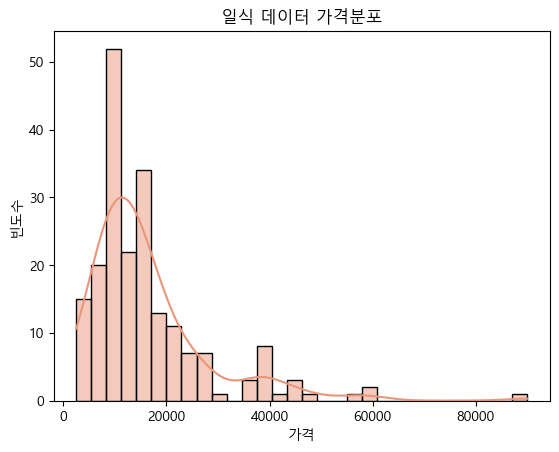

In [ ]:
sns.histplot(data=df_japan, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('일식 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
df_japan.sort_values(by='가격').head()

,메뉴,가격,가게명,주메뉴,동
4462,계란구이,2500,츠나토리,일식,화양동
1784,계란 유부초밥,2500,유부야 자양점,일식,자양동
4403,참치마요 유부초밥,2500,유부야 자양점,일식,자양동
4371,새우,2500,소바쿠,일식,능동
4481,통마늘&은행꼬치,3000,이자카나,일식,화양동


In [ ]:
df_japan = df_japan[df_japan['가격'] >= 6000].copy()
df_japan.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
4461,숙성 연어,48000,악당,일식,화양동
1689,사시미 (점심특선),55000,연스시,일식,구의동
1842,사시미 모리아와세 2인,58000,악당,일식,화양동
1745,야끼니꾸 2인셋트,59900,츠쿠요미 군자점,일식,군자동
4320,모듬생선회A(1인분),90000,서경,일식,구의동


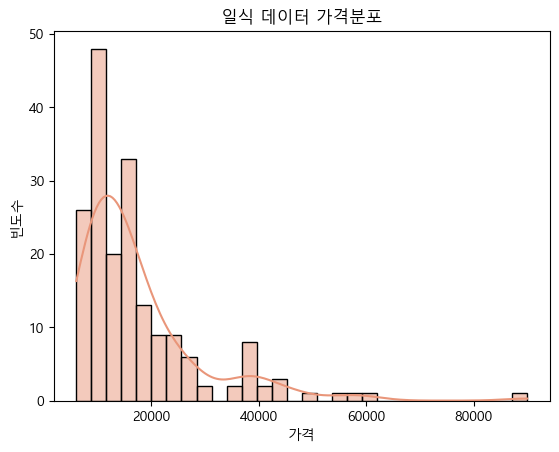

In [ ]:
sns.histplot(data=df_japan, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('일식 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

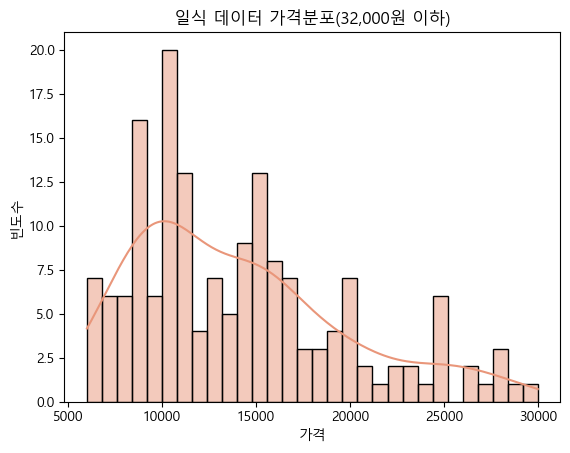

In [ ]:
sns.histplot(data=df_japan[df_japan['가격'] <= 32000], 
             x='가격', bins=30, kde=True, color='darksalmon')
plt.title('일식 데이터 가격분포(32,000원 이하)') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
# final data

df_japan = df_japan[df_japan['가격'] <= 32000]

### **9. '카페' 데이터 이상치 처리**

In [ ]:
df_cafe['가격'].describe()

count       954.000000
mean       5380.678197
std        5505.413756
min        1000.000000
25%        3500.000000
50%        4450.000000
75%        5800.000000
max      123467.000000
Name: 가격, dtype: float64

In [ ]:
df_cafe = df_cafe[df_cafe['가격'] <= 12000].copy()
df_cafe.sort_values(by='가격').tail()

,메뉴,가격,가게명,주메뉴,동
2610,[1인분]타코야끼（맛 선택1~2＋음료1）,11500,쏭타코야끼카페,카페,화양동
2339,치킨치즈베이컨베이글,11900,빈앤도우,카페,군자동
2144,수제청,11900,소담미담 서울중곡점,카페,중곡동
4920,고당고 황금 '태국망고',12000,우아한과일&카페 건대점,카페,구의동
2186,목장우유 카이막과 통바게트,12000,버터럼 부티크광장,카페,광장동


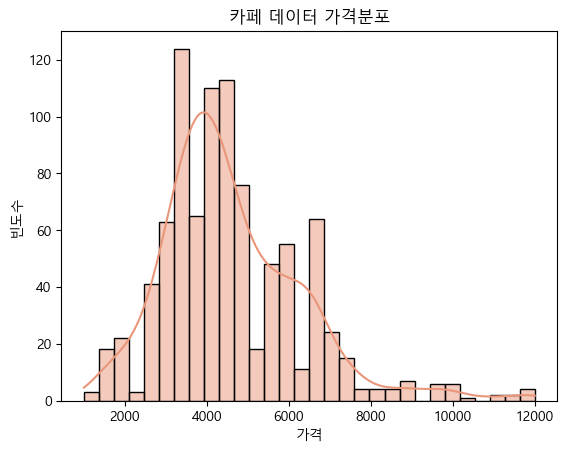

In [ ]:
sns.histplot(data=df_cafe, x='가격', bins=30, kde=True, color='darksalmon')
plt.title('카페 데이터 가격분포') 
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
# final data

df_cafe = df_cafe[df_cafe['가격'] <= 9500].copy()

## **4. Final Data**

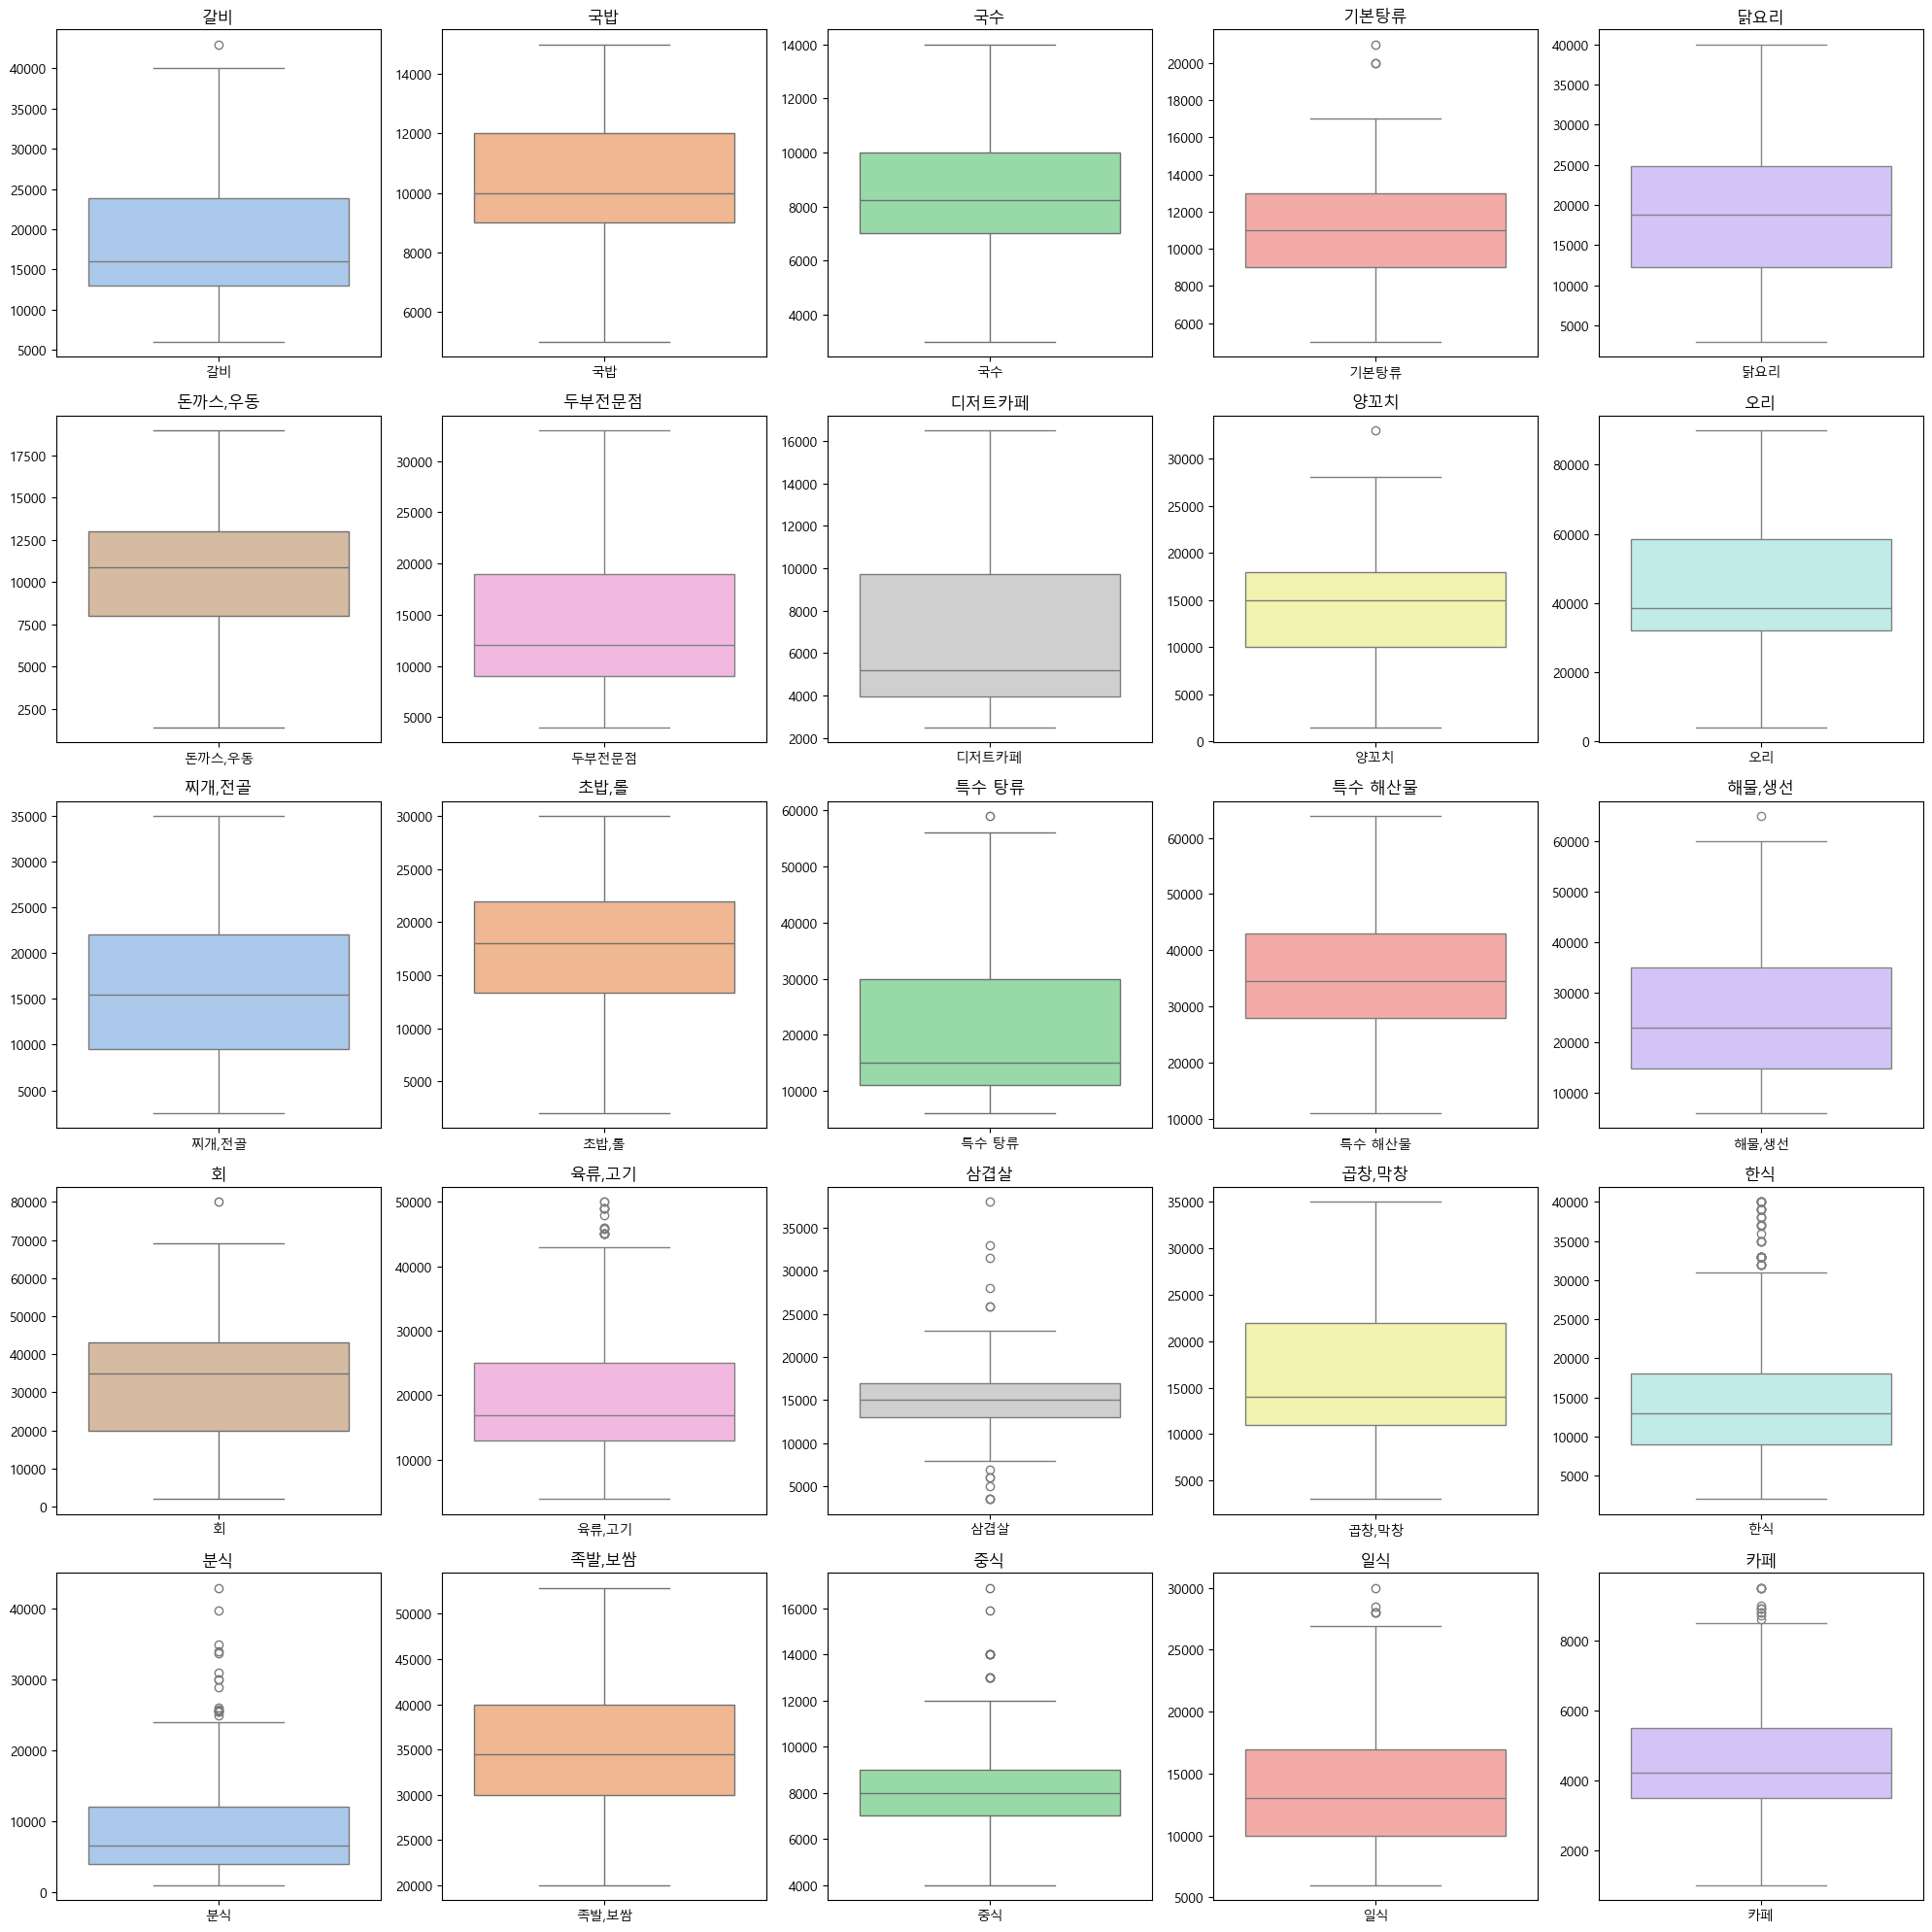

In [ ]:
df_long = pd.concat([df_left, df_meat, df_pork, df_gop, df_kor, df_bun, df_jok,
                      df_china, df_japan, df_cafe], ignore_index=True)

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))  
axes = axes.flatten()  

menu_list = df_long['주메뉴'].unique()
palette = sns.color_palette("pastel", n_colors=len(menu_list))

for i, (menu, color) in enumerate(zip(menu_list, palette)):
    sns.boxplot(x='주메뉴', y='가격', data=df_long[df_long['주메뉴'] == menu], ax=axes[i],
                hue='주메뉴', palette=[color], legend=False)
    axes[i].set_title(menu)
    #axes[i].set_ylim(0,80000)
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   메뉴      4653 non-null   object
 1   가격      4653 non-null   int64 
 2   가게명     4653 non-null   object
 3   주메뉴     4653 non-null   object
 4   동       4653 non-null   object
dtypes: int64(1), object(4)
memory usage: 181.9+ KB


In [ ]:
df_long['평균가격'] = df_long.groupby('주메뉴')['가격'].transform('mean').round(2)
df_long.head()

,메뉴,가격,가게명,주메뉴,동,평균가격
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48


In [ ]:
def 점수계산(row):
    가격 = row['가격']
    평균 = row['평균가격']
    
    if 가격 <= 평균:
        감점비율 = (평균- 가격) / 평균
        score = 70 * (감점비율)
    else:
        score = 0
    
    return max(score, 0)  # 점수는 최소 0

df_long['가격점수'] = df_long.apply(점수계산, axis=1)
df_long.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48,0.000000
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48,0.000000
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612


In [ ]:
df_long.shape

(4653, 7)

In [ ]:
df_long[df_long['가격점수'] > 0]

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612
5,제육볶음,10000,59년왕십리돼지숯불갈비 성수점,갈비,자양동,18934.48,33.030408
6,등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612
...,...,...,...,...,...,...,...
4645,아메리카노,3200,이디야커피 구의사거리점,카페,구의동,4487.85,20.087458
4646,아메리카노(HOT),3000,담아,카페,구의동,4487.85,23.206992
4647,에스프레소,4000,바이온,카페,구의동,4487.85,7.609323
4648,클래식 스콘,2200,포그,카페,구의동,4487.85,35.685128


In [ ]:
df_long[df_long['가격점수'] > 0].sort_values(by='가격점수', ascending=False).head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수
1487,쌈야채추가,2000,청정활어회직판장,회,중곡동,33927.84,65.873595
968,오리똥집(1인),4000,핫오리 건대점,오리,자양동,41750.00,63.293413
915,신강양꼬치,1500,신강양꼬치 건대직영점,양꼬치,자양동,15101.23,63.046924
3049,부산어묵,1000,감탄떡볶이 중곡점,분식,중곡동,9028.96,62.247169
3278,떡볶이 (컵),1000,분식집,분식,자양동,9028.96,62.247169


## **5. 위생 데이터 추가**

In [ ]:
df_long.to_csv('광진구 가격점수 원본.csv', index=False, encoding='utf-8-sig')

In [ ]:
df_filtered = df_long[df_long['가격점수'] > 0]
df_filtered.to_csv('광진구 가격점수 통과.csv', index=False, encoding='utf-8-sig')

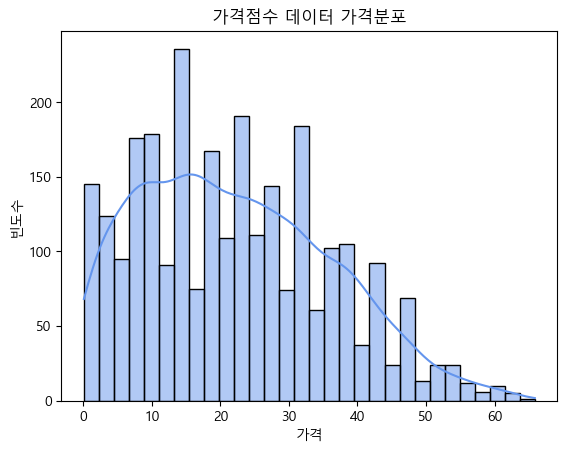

In [ ]:
sns.histplot(data=df_filtered, x='가격점수', bins=30, kde=True, color='cornflowerblue')
plt.title('가격점수 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [ ]:
df_filtered[(df_filtered['가격점수'] > 40) & (df_filtered['가격점수'] < 50)]


,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수
13,무한리필 (미취학아동),6000,갈비공판장 자양점,갈비,자양동,18934.48,47.818245
22,생고기,7000,돈조은날,갈비,화양동,18934.48,44.121286
30,뚝배기갈비찜,7000,아라주는 갈비집,갈비,중곡동,18934.48,44.121286
69,삼겹살,7000,돈조은날,갈비,화양동,18934.48,44.121286
73,뚝배기 불고기,7000,아라주는 갈비집,갈비,중곡동,18934.48,44.121286
...,...,...,...,...,...,...,...
4444,에스프레소,1500,큐베리 중곡점,카페,중곡동,4487.85,46.603496
4557,아메리카노,1700,피에스타7커피 구의점,카페,구의동,4487.85,43.483962
4570,아메리카노,1500,와플그란데,카페,군자동,4487.85,46.603496
4581,아메리카노 (HOT),1500,빽다방 군자역점,카페,군자동,4487.85,46.603496
